L06:Black hole binary formation channels using gaussians mixture.
    We are given the distribution of masses as input data. We whish to determine the number of formation
    modes for black hole binaries (equal to the number of gaussians that best fits the data)

In [1]:
import numpy as np
import scipy
from matplotlib import pyplot as plt
import sklearn

Text(0.5, 0, 'Black hole mass $[M_\\odot]$')

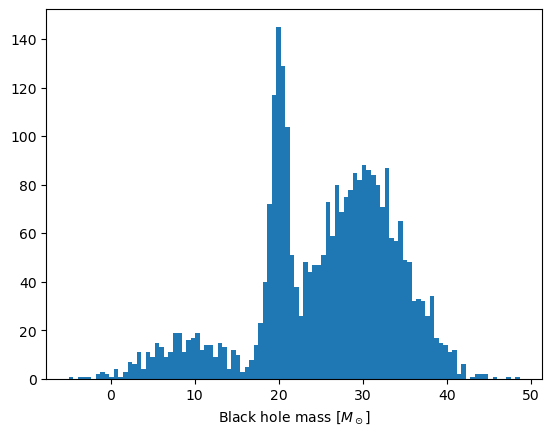

In [2]:
#loading the data
data = np.load('formationchannels.npy')
plt.hist(data, 100) #preliminary histogram plot
plt.xlabel('Black hole mass $[M_\odot]$')


We use the AIC as a measure of goodness of the fit (to infer the number of modes)

[ 1  2  3  4  5  6  7  8  9 10]


Text(0, 0.5, 'AIC')

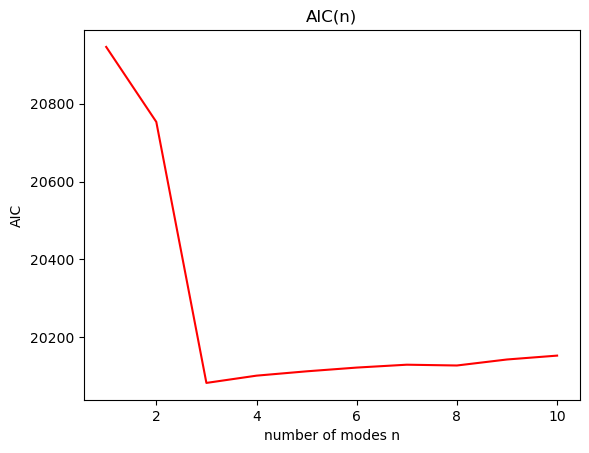

In [6]:
import sklearn.mixture

aic = []

trial_models = [sklearn.mixture.GaussianMixture(n) for n in range(1, 11)]

#fitting the data with a varible number of gaussians (#modes)
for model_n in trial_models:

    model_n.fit(data)
    aic.append(model_n.aic(data))


#plotting the AIC as a function of the number of modes
x_vals = np.arange(1, 11)
print(x_vals)
plt.plot(x_vals, aic, c='red')
plt.title('AIC(n)')
plt.xlabel('number of modes n')
plt.ylabel('AIC')

We select the model that minimizes the value of the AIC

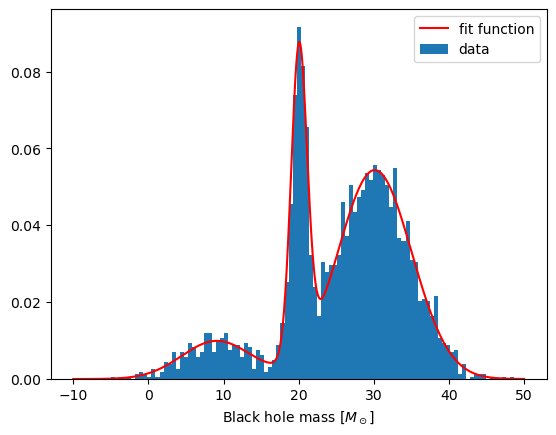

In [13]:

#fitting the data with a sum of n gaussians, with n minimizing the AIC value
n_modes_index = np.argsort(aic)[0]
model = trial_models[n_modes_index]

x_grid = np.linspace(-10, 50, 1000)
fit_function = [] #array to store the values of the fitting function
for x in x_grid:
    log_val = model.score_samples(x.reshape(-1, 1))
    fit_function.append(np.exp(log_val))

#plotting the data histogram, along with the fitting function
plt.plot(x_grid, fit_function, c='red', label='fit function')
plt.hist(data, 100, density=True, label='data')
plt.xlabel('Black hole mass $[M_\odot]$')
plt.legend()


We now plot the fitting functions for different number of modes (in particular the optimal, one more and one less)

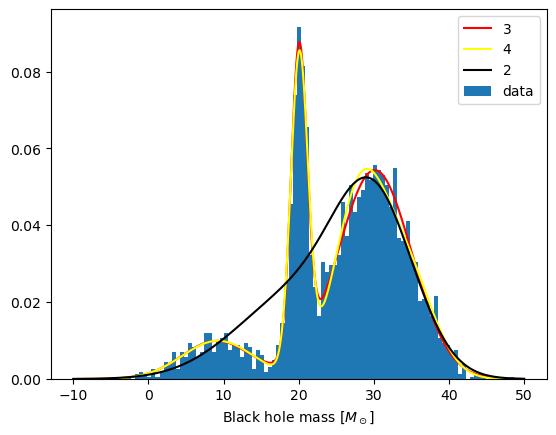

In [ ]:
model_p1 = trial_models[n_modes_index+1]
model_m1 = trial_models[n_modes_index-1]

fit_function_p1 = [] #array to store the values of the fitting function with one too many modes
for x in x_grid:
    log_val = model_p1.score_samples(x.reshape(-1, 1))
    fit_function_p1.append(np.exp(log_val))

fit_function_m1 = [] #array to store the values of the fitting function with a missing mode
for x in x_grid:
    log_val = model_m1.score_samples(x.reshape(-1, 1))
    fit_function_m1.append(np.exp(log_val))

#plot
plt.plot(x_grid, fit_function, c='red', label=str(n_modes_index+1))
plt.plot(x_grid, fit_function_p1, c='yellow', label=str(n_modes_index+2))
plt.plot(x_grid, fit_function_m1, c='black', label=str(n_modes_index))
plt.hist(data, 100, density=True, label='data')
plt.xlabel('Black hole mass $[M_\odot]$')
plt.legend()
